<div style="padding: 20px; background-color: #f8f9fa; border-left: 10px solid #007bff; border-radius: 5px;">
    <h1 style="color: #007bff;">🏠 Post-Pandemic Housing Market Analysis</h1>
    <h3>Preprocessing & Feature Engineering Pipeline</h3>
    <p><b>Group 4 | 3CSE Machine Learning</b></p>
    <hr>
    <p><b>Objective:</b> This notebook processes Zillow Real Estate data to investigate non-linear determinants of housing prices during the WFH (Work From Home) era. We aim to bridge hyper-local price data with structural economic indicators to prepare a high-fidelity tensor for <b>Multiple Linear Regression</b> and <b>Decision Tree (CART)</b> modeling.</p>
</div>


## 🛠️ Environment Setup

In [ ]:
import pandas as pd
import numpy as np
# from google.colab import drive
import os

ModuleNotFoundError: No module named 'google.colab'

## 📂 Data Acquisition

In [ ]:
# 1. Mount Drive
# drive.mount('/content/drive',force_remount=True)

# 2. Define your specific path
# Pro-tip: Use the full string exactly as it appears in Colab's file explorer
base_path = 'Dataset/'

# 3. List of your files (using the exact names you provided)
files = {
    'zhvi': 'metro_zhvi.csv',
    'rent': 'metro_zori.csv',
    'for_sale': 'metro_forsale.csv',
    'new_listings': 'metro_new_listings.csv',
    'days_pending': 'metro_med_days_to_pending.csv',
    'price_cuts': 'metro_shrlist_prcut.csv',
    'income_needed': 'metro_new_homeowner_income_needed.csv',
    'zhvi_1b': 'metro_zhvi_1_bdrm.csv',
    'zhvi_2b': 'metro_zhvi_2_bdrm.csv',
    'zhvi_3b': 'metro_zhvi_3_bdrm.csv',
    'zhvi_4b': 'metro_zhvi_4_bdrm.csv',
    'zhvi_5b': 'metro_zhvi_5plus_bdrm.csv',
    'market_heat_index': 'metro_market_heat_index.csv',
    'new_homeowner_affordability': 'metro_new_homeowner_affordability.csv'
}

Mounted at /content/drive


In [ ]:
# 4. Load dataframes into a dictionary
dfs = {}
print("--- Starting Data Load ---")
for key, filename in files.items():
    full_path = os.path.join(base_path, filename)
    if os.path.exists(full_path):
        dfs[key] = pd.read_csv(full_path)
        print(f"✅ Success: {key} loaded. Shape: {dfs[key].shape}")
    else:
        print(f"❌ Error: File not found at {full_path}")

--- Starting Data Load ---
✅ Success: zhvi loaded. Shape: (895, 320)
✅ Success: rent loaded. Shape: (719, 140)
✅ Success: for_sale loaded. Shape: (928, 102)
✅ Success: new_listings loaded. Shape: (927, 102)
✅ Success: days_pending loaded. Shape: (769, 102)
✅ Success: price_cuts loaded. Shape: (928, 102)
✅ Success: income_needed loaded. Shape: (390, 176)
✅ Success: zhvi_1b loaded. Shape: (671, 320)
✅ Success: zhvi_2b loaded. Shape: (851, 320)
✅ Success: zhvi_3b loaded. Shape: (884, 320)
✅ Success: zhvi_4b loaded. Shape: (855, 320)
✅ Success: zhvi_5b loaded. Shape: (758, 320)
✅ Success: market_heat_index loaded. Shape: (928, 104)
✅ Success: new_homeowner_affordability loaded. Shape: (390, 176)


## ⚙️ Data Reshaping & Structural Alignment

In [ ]:
def process_and_merge(dfs):
    # 1. THE MELT: Transforming horizontal date columns into vertical rows
    melted_dfs = {}
    id_vars = ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName']

    print("--- Reshaping Data ---")
    for key, df in dfs.items():
        # Identify date columns (they start with '20' or '19')
        date_cols = [col for col in df.columns if col.startswith(('20', '19'))]

        # Melt the dataframe
        df_long = df.melt(id_vars=id_vars, value_vars=date_cols,
                          var_name='Date', value_name=key)

        # Convert Date string to datetime objects for accurate merging
        df_long['Date'] = pd.to_datetime(df_long['Date'])
        melted_dfs[key] = df_long
        print(f"Reshaped {key}...")

    # 2. THE MASTER MERGE: Stitching all 12 tables together
    # We start with 'zhvi' as our base anchor
    master_df = melted_dfs['zhvi']

    print("\n--- Merging Tables ---")
    # List of keys to merge (excluding the anchor 'zhvi')
    other_keys = [k for k in melted_dfs.keys() if k != 'zhvi']

    for key in other_keys:
        # We only need RegionID, Date, and the actual Data Value for the merge
        subset = melted_dfs[key][['RegionID', 'Date', key]]
        master_df = pd.merge(master_df, subset, on=['RegionID', 'Date'], how='left')
        print(f"Merged {key} into master...")

    # 3. FEATURE ENGINEERING: Creating non-linear proxies
    print("\n--- Engineering Features ---")

    # Space Premium: Ratio of 4-bedroom to 2-bedroom prices
    # Formula: $Space\_Premium = \frac{ZHVI_{4BR}}{ZHVI_{2BR}}$
    master_df['space_premium'] = master_df['zhvi_4b'] / master_df['zhvi_2b']

    # Era Toggle: Categorizing the market shift (Interest Rate Hike Era)
    # 0 = Pandemic/Low-Rate, 1 = Post-Pandemic/High-Rate
    master_df['is_post_pandemic'] = (master_df['Date'] >= '2022-04-01').astype(int)

    # 4. CLEANING: Handling missing values and sorting
    print("--- Cleaning & Filling Gaps ---")
    master_df = master_df.sort_values(['RegionID', 'Date'])

    # Forward-fill (carry last known value) then backward-fill within each Metro group
    master_df = master_df.groupby('RegionID').apply(lambda x: x.ffill().bfill()).reset_index(drop=True)

    # Drop rows that are still NaN (where no data exists for that Metro at all)
    master_df.dropna(inplace=True)

    return master_df

# Execute the pipeline
master_df = process_and_merge(dfs)
print(f"\nFinal Master Dataframe Shape: {master_df.shape}")

--- Reshaping Data ---
Reshaped zhvi...
Reshaped rent...
Reshaped for_sale...
Reshaped new_listings...
Reshaped days_pending...
Reshaped price_cuts...
Reshaped income_needed...
Reshaped zhvi_1b...
Reshaped zhvi_2b...
Reshaped zhvi_3b...
Reshaped zhvi_4b...
Reshaped zhvi_5b...
Reshaped market_heat_index...
Reshaped new_homeowner_affordability...

--- Merging Tables ---
Merged rent into master...
Merged for_sale into master...
Merged new_listings into master...
Merged days_pending into master...
Merged price_cuts into master...
Merged income_needed into master...
Merged zhvi_1b into master...
Merged zhvi_2b into master...
Merged zhvi_3b into master...
Merged zhvi_4b into master...
Merged zhvi_5b into master...
Merged market_heat_index into master...
Merged new_homeowner_affordability into master...

--- Engineering Features ---
--- Cleaning & Filling Gaps ---


/tmp/ipykernel_8099/576788114.py:50: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  master_df = master_df.groupby('RegionID').apply(lambda x: x.ffill().bfill()).reset_index(drop=True)



Final Master Dataframe Shape: (112455, 22)


/tmp/ipykernel_8099/576788114.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  master_df = master_df.groupby('RegionID').apply(lambda x: x.ffill().bfill()).reset_index(drop=True)


In [ ]:
master_df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,Date,zhvi,rent,for_sale,new_listings,...,income_needed,zhvi_1b,zhvi_2b,zhvi_3b,zhvi_4b,zhvi_5b,market_heat_index,new_homeowner_affordability,space_premium,is_post_pandemic
945,394299,251,"Abilene, TX",msa,TX,2000-01-31,110160.691527,794.734504,856.0,233.0,...,26823.496846,43875.104523,62226.945988,114218.361478,197258.479399,241278.729993,42.0,0.19137,3.169985,0
946,394299,251,"Abilene, TX",msa,TX,2000-02-29,110160.691527,794.734504,856.0,233.0,...,26823.496846,43875.104523,62226.945988,114218.361478,197258.479399,241278.729993,42.0,0.19137,3.169985,0
947,394299,251,"Abilene, TX",msa,TX,2000-03-31,110160.691527,794.734504,856.0,233.0,...,26823.496846,43875.104523,62226.945988,114218.361478,197258.479399,241278.729993,42.0,0.19137,3.169985,0
948,394299,251,"Abilene, TX",msa,TX,2000-04-30,110160.691527,794.734504,856.0,233.0,...,26823.496846,43875.104523,62226.945988,114218.361478,197258.479399,241278.729993,42.0,0.19137,3.169985,0
949,394299,251,"Abilene, TX",msa,TX,2000-05-31,110160.691527,794.734504,856.0,233.0,...,26823.496846,43875.104523,62226.945988,114218.361478,197258.479399,241278.729993,42.0,0.19137,3.169985,0


## 📊 EXPLORATORY DATA ANALYSIS

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### 📊 1. Distribution of Home Values (ZHVI)

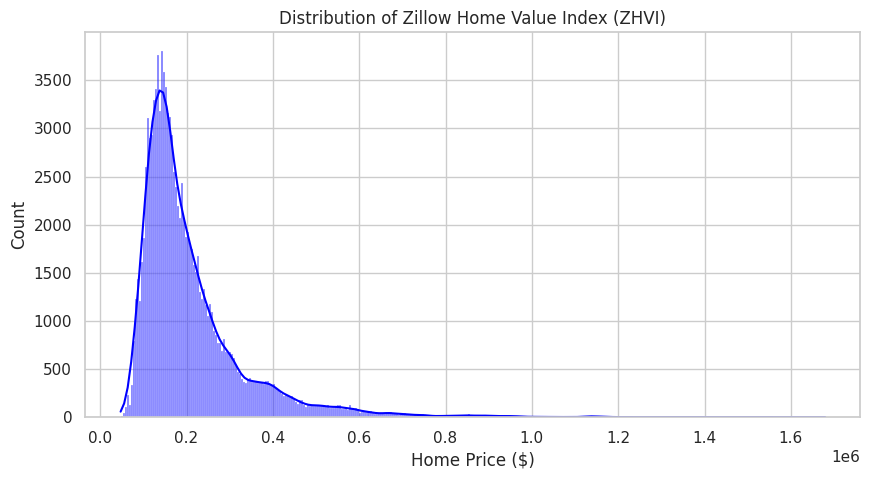

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(master_df['zhvi'], kde=True, color='blue')
plt.title('Distribution of Zillow Home Value Index (ZHVI)')
plt.xlabel('Home Price ($)')
plt.show()

### 🌡️ 2. Feature Correlation Matrix

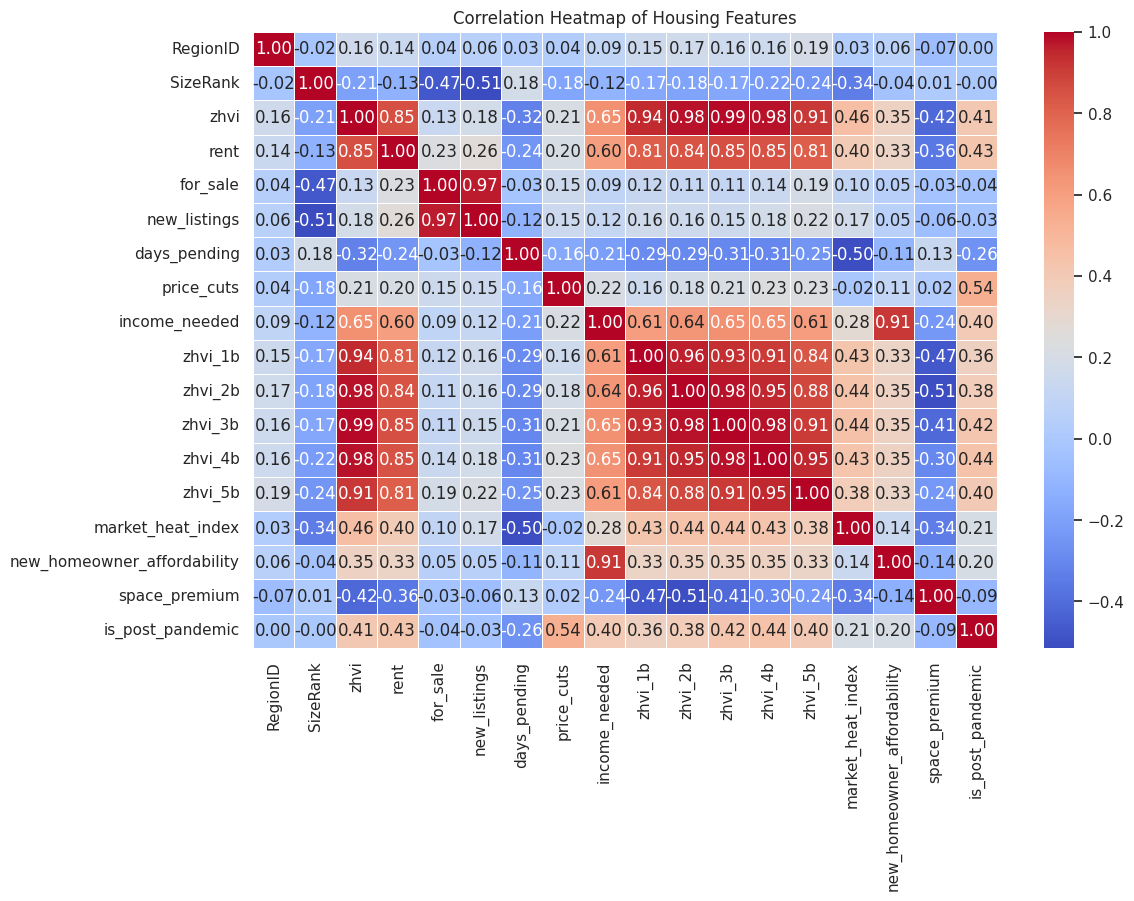

In [ ]:
# Select only numerical columns for correlation
numeric_cols = master_df.select_dtypes(include=[np.number]).columns
corr = master_df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Housing Features')
plt.show()

### 🏢 3. The "Space Premium" Trend

/tmp/ipykernel_8099/1823257848.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=master_df, x='Date', y='space_premium', ci=None)


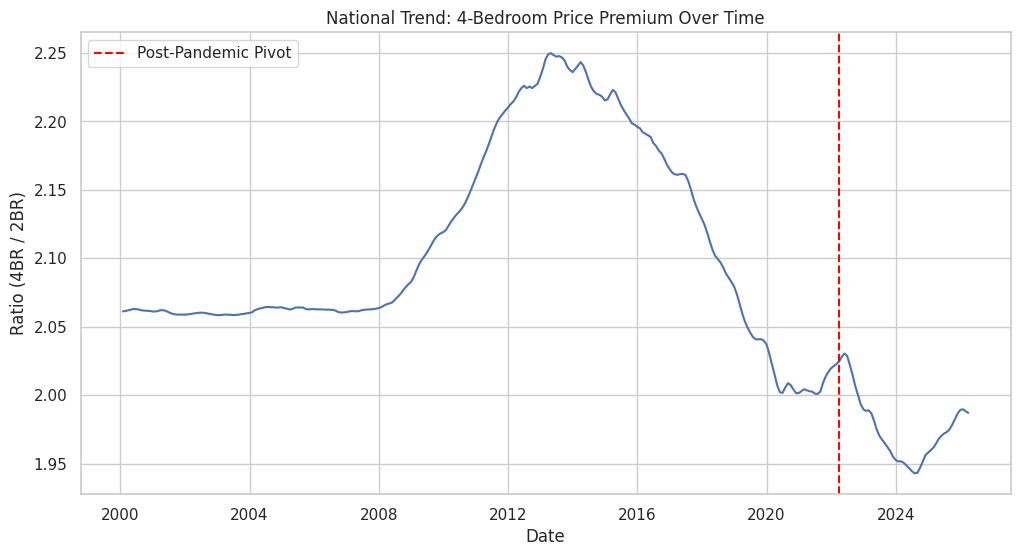

In [ ]:
sns.lineplot(data=master_df, x='Date', y='space_premium', ci=None)
plt.axvline(pd.to_datetime('2022-04-01'), color='red', linestyle='--', label='Post-Pandemic Pivot')
plt.title('National Trend: 4-Bedroom Price Premium Over Time')
plt.ylabel('Ratio (4BR / 2BR)')
plt.legend()
plt.show()

## 🛠️ Section 2: Feature Encoding & Chronological Splitting
We apply **Label Encoding** to State names and **One-Hot Encoding** to Region types. To prevent data leakage, we use a chronological split (80/20) rather than a random shuffle.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import pandas as pd

# 1. Sort by date first (Essential for time-series)
master_df = master_df.sort_values('Date')

# 2. Set a cut-off date for 'Post-Pandemic' exposure
split_date = '2023-01-01'
train_df = master_df[master_df['Date'] < split_date].copy()
test_df = master_df[master_df['Date'] >= split_date].copy()

# --- NEW: Safe Target Encoding Implementation ---
# Calculate means from training set only to prevent leakage
state_target_means = train_df.groupby('StateName')['zhvi'].mean()

# Map the means to create the 'state_encoded' feature
train_df['state_encoded'] = train_df['StateName'].map(state_target_means)
test_df['state_encoded'] = test_df['StateName'].map(state_target_means)

# Handle unseen states in the test set using the global training mean
global_train_mean = train_df['zhvi'].mean()
test_df['state_encoded'] = test_df['state_encoded'].fillna(global_train_mean)
# ------------------------------------------------

# 3. Define X and y
# Note: 'StateName' is dropped, but our new 'state_encoded' is NOT in this list, so it stays.
cols_to_drop = [
    'RegionID', 'RegionName', 'Date', 'RegionType', 'StateName', 'SizeRank',
    'zhvi', 'zhvi_1b', 'zhvi_2b', 'zhvi_3b', 'zhvi_4b', 'zhvi_5b',
    'new_listings', 'income_needed'
]

X_train_raw = train_df.drop(columns=cols_to_drop)
X_test_raw = test_df.drop(columns=cols_to_drop)
y_train = train_df['zhvi']
y_test = test_df['zhvi']

print(f"Training on data up to {train_df['Date'].max()}")
print(f"Testing on data from {test_df['Date'].min()} to {test_df['Date'].max()}")
print(f"Feature count: {X_train_raw.shape[1]} (New feature 'state_encoded' included)")

Training on data up to 2022-12-31 00:00:00
Testing on data from 2023-01-31 00:00:00 to 2026-03-31 00:00:00
Feature count: 9 (New feature 'state_encoded' included)


In [ ]:
# 1. Standardization (Mean=0, Variance=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Convert to DataFrames
X_train = pd.DataFrame(X_train_scaled, columns=X_train_raw.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test_raw.columns)

# 2. Export to Google Drive
export_folder = os.path.join(base_path, 'Model_Ready_Exports')
if not os.path.exists(export_folder): os.makedirs(export_folder)

sets = {
    'X_train.parquet': X_train, 'X_test.parquet': X_test,
    'y_train.parquet': y_train.to_frame(), 'y_test.parquet': y_test.to_frame()
}

for name, data in sets.items():
    data.to_parquet(os.path.join(export_folder, name), index=False)

# Save Scaler and Label Mapping
joblib.dump(scaler, os.path.join(export_folder, 'feature_scaler.pkl'))

print(f"✨ Successfully exported 4 datasets and scaler to: {export_folder}")

In [ ]:
# ==========================================
# Environment Setup & Data Ingestion
# ==========================================

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os

# For Reproducibility
np.random.seed(42)

# Path to the model-ready data exports (relative to this notebook)
dataset_path = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'Dataset', 'Model_Ready_Exports')

print("=" * 60)
print("LOADING DATA & APPLYING TARGET TRANSFORMATION")
print("=" * 60)

try:
    # Load the datasets
    X_train = pd.read_parquet(os.path.join(dataset_path, 'X_train.parquet'))
    X_test = pd.read_parquet(os.path.join(dataset_path, 'X_test.parquet'))
    y_train = pd.read_parquet(os.path.join(dataset_path, 'y_train.parquet'))
    y_test = pd.read_parquet(os.path.join(dataset_path, 'y_test.parquet'))

    # Load scaler in case we need to inverse transform features later
    scaler = joblib.load(os.path.join(dataset_path, 'feature_scaler.pkl'))

    # Extract the 1D series from the y dataframes
    y_train_raw = y_train.squeeze()
    y_test_raw = y_test.squeeze()

    # Apply log1p transformation to the target variables
    y_train_log = np.log1p(y_train_raw)
    y_test_log = np.log1p(y_test_raw)

    print("✅ Datasets loaded successfully!")
    print(f"X_train shape: {X_train.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"y_train_log shape: {y_train_log.shape}")

    print("\nTarget Variable (zhvi) Summary:")
    print(f"Original y_train Mean: ${y_train_raw.mean():,.2f}")
    print(f"Log-Transformed y_train Mean: {y_train_log.mean():.4f}")

    # Display the first few rows of our training features
    print("\nFirst 5 rows of X_train:")
    display(X_train.head())

except Exception as e:
    print(f"Error loading files: {e}")
    print("Please double-check the 'dataset_path' variable.")

Mounted at /content/drive
LOADING DATA & APPLYING TARGET TRANSFORMATION
✅ Datasets loaded successfully!
X_train shape: (98532, 9)
X_test shape: (13923, 9)
y_train_log shape: (98532,)

Target Variable (zhvi) Summary:
Original y_train Mean: $193,366.02
Log-Transformed y_train Mean: 12.0586

First 5 rows of X_train:


,rent,for_sale,days_pending,price_cuts,market_heat_index,new_homeowner_affordability,space_premium,is_post_pandemic,state_encoded
0,-0.786191,-0.348168,0.233897,0.129621,-0.091809,-0.204989,2.007224,-0.183597,-0.627317
1,-0.591568,-0.391177,2.527199,-0.890090,-1.169172,-0.220649,-0.127020,-0.183597,0.204456
2,-0.192740,0.944134,-1.107468,0.251143,0.529746,-0.343586,0.190462,-0.183597,-0.333845
3,-0.319452,-0.098773,-0.242071,0.493899,0.405435,-0.218287,-0.322654,-0.183597,2.712180
4,-1.097279,-0.374623,-0.415150,-0.513307,0.032502,-0.253359,0.453756,-0.183597,-0.627317


In [ ]:
# ==========================================
# Train Multiple Linear Regression
# ==========================================

print("=" * 60)
print("TRAINING MULTIPLE LINEAR REGRESSION")
print("=" * 60)

# Initialize the model
mlr_model = LinearRegression()

# Fit the model using training set (predicting the log-transformed target)
mlr_model.fit(X_train, y_train_log)

# Extract and display what the model learned
print(f"Intercept (Beta_0): {mlr_model.intercept_:.4f}\n")

print("Feature Coefficients (Beta_1 to Beta_n):")
print("Note: Because features were standardized, larger absolute values indicate stronger impact.\n")

# Zip the column names with the coefficients for easy reading
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': mlr_model.coef_
})

# Sort by absolute value to see which features have the strongest impact
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False).drop('Abs_Coefficient', axis=1).reset_index(drop=True)

display(coefficients)

TRAINING MULTIPLE LINEAR REGRESSION
Intercept (Beta_0): 12.0586

Feature Coefficients (Beta_1 to Beta_n):
Note: Because features were standardized, larger absolute values indicate stronger impact.



,Feature,Coefficient
0,rent,0.205389
1,market_heat_index,0.088828
2,state_encoded,0.084938
3,space_premium,-0.076276
4,days_pending,-0.043229
5,price_cuts,0.027659
6,is_post_pandemic,0.025667
7,new_homeowner_affordability,0.022907
8,for_sale,0.006595


In [ ]:
# ==========================================
# Baseline Evaluation Metrics
# ==========================================

print("=" * 60)
print("EVALUATING MLR BASELINE ON HOLDOUT SET")
print("=" * 60)

# Generate predictions on the untouched test set (in log scale)
y_pred_log = mlr_model.predict(X_test)

# Reverse the log transformation to get actual dollar values
y_pred_actual = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test_log)

# Calculate Metrics

# RMSE
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

# MAE
mae = mean_absolute_error(y_test_actual, y_pred_actual)

# MAPE
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

# R-squared
r2 = r2_score(y_test_actual, y_pred_actual)

# Rresults
print(f"Root Mean Squared Error (RMSE) : ${rmse:,.2f}")
print(f"Mean Absolute Error (MAE)      : ${mae:,.2f}")
print(f"Mean Absolute Pct Error (MAPE) : {mape:.2f}%")
print(f"R-squared (R²)                 : {r2:.4f}")

EVALUATING MLR BASELINE ON HOLDOUT SET
Root Mean Squared Error (RMSE) : $74,978.28
Mean Absolute Error (MAE)      : $50,290.33
Mean Absolute Pct Error (MAPE) : 14.36%
R-squared (R²)                 : 0.8271


CHECKING GAUSS-MARKOV ASSUMPTIONS

--- Variance Inflation Factor (VIF) ---
Rule of thumb: VIF > 5-10 indicates problematic multicollinearity.



,Feature,VIF
0,rent,1.993862
1,state_encoded,1.933829
2,market_heat_index,1.632840
3,days_pending,1.373447
4,space_premium,1.316482
5,is_post_pandemic,1.219339
6,for_sale,1.205502
7,price_cuts,1.173895
8,new_homeowner_affordability,1.076981


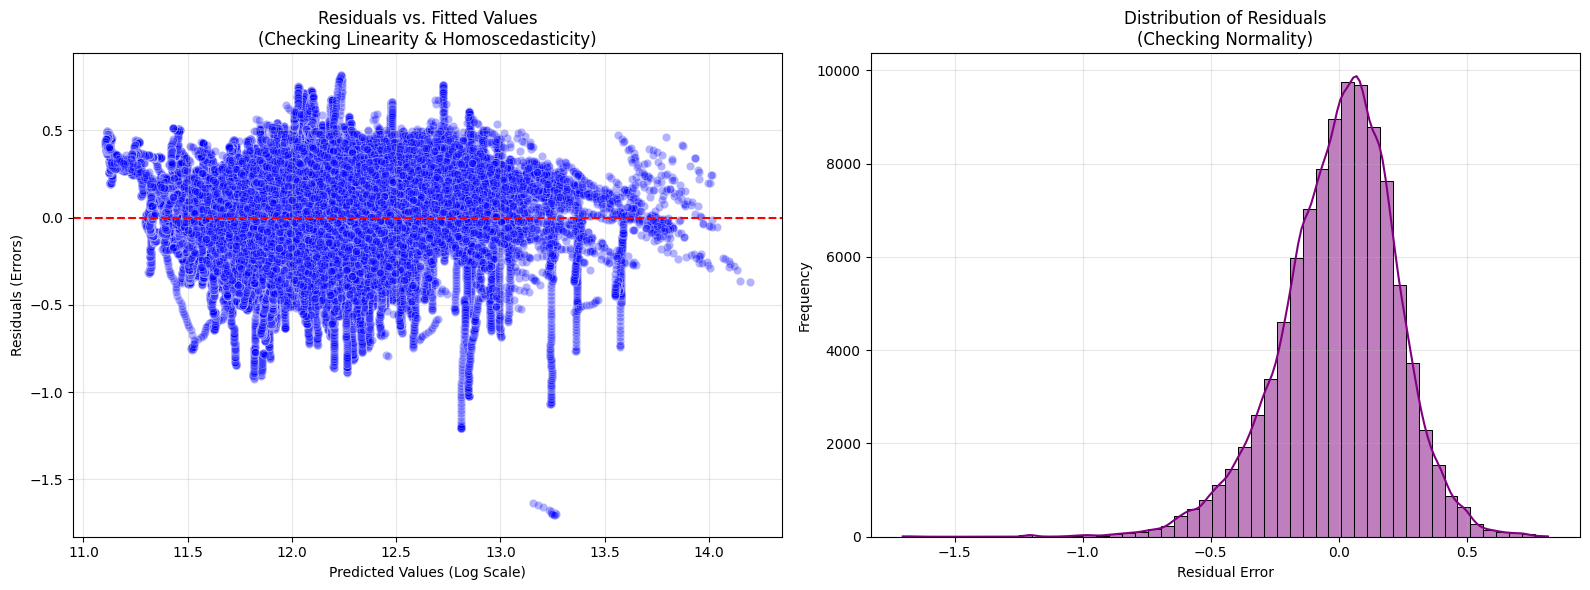

In [ ]:
# ==========================================
# Gauss-Markov Diagnostics
# ==========================================
print("=" * 60)
print("CHECKING GAUSS-MARKOV ASSUMPTIONS")
print("=" * 60)

# Calculate predictions and residuals on the training set
y_train_pred_log = mlr_model.predict(X_train)
residuals = y_train_log - y_train_pred_log

# Assumption 2: Independence (Multicollinearity via VIF)
print("\n--- Variance Inflation Factor (VIF) ---")
print("Rule of thumb: VIF > 5-10 indicates problematic multicollinearity.\n")

vif_data = pd.DataFrame()
vif_data["Feature"] = X_train.columns
# Calculate VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(len(X_train.columns))]
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)
display(vif_data)

# Visual Diagnostics Setup
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Assumption 1 & 3: Linearity and Homoscedasticity (Residuals vs Fitted)
sns.scatterplot(x=y_train_pred_log, y=residuals, alpha=0.3, ax=axes[0], color='blue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Residuals vs. Fitted Values\n(Checking Linearity & Homoscedasticity)')
axes[0].set_xlabel('Predicted Values (Log Scale)')
axes[0].set_ylabel('Residuals (Errors)')
axes[0].grid(True, alpha=0.3)

# Assumption 4: Normality of Residuals (Distribution Plot)
sns.histplot(residuals, kde=True, ax=axes[1], color='purple', bins=50)
axes[1].set_title('Distribution of Residuals\n(Checking Normality)')
axes[1].set_xlabel('Residual Error')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# Reproducibility Export & Handoff
# ==========================================
print("=" * 60)
print("EXPORTING MLR ARTIFACTS FOR SHAP ANALYSIS")
print("=" * 60)

# Save the trained model
model_save_path = os.path.join(dataset_path, "mlr_model_final.joblib")
joblib.dump(mlr_model, model_save_path)
print(f"Model saved successfully to: {model_save_path}")

# Create a results dictionary for reproducibility
results_summary = {
    "model": "Multiple Linear Regression (Baseline)",
    "target_transformation": "log1p",
    "metrics": {
        "r2_test": round(r2, 4),
        "rmse_test": round(rmse, 2),
        "mae_test": round(mae, 2),
        "mape_test_pct": round(mape, 2)
    },
    "model_parameters": {
        "intercept_log_scale": round(mlr_model.intercept_, 4),
        "features_used": list(X_train.columns)
    },
    "random_state": 42
}

# Save the results dictionary to JSON
summary_path = os.path.join(dataset_path, "mlr_baseline_summary.json")
with open(summary_path, 'w') as f:
    json.dump(results_summary, f, indent=4)

print(f"Baseline results summary saved to: {summary_path}\n")

# 4. Display the final JSON output for confirmation
print("Final Exported Results:")
print(json.dumps(results_summary, indent=4))

EXPORTING MLR ARTIFACTS FOR SHAP ANALYSIS
Model saved successfully to: /content/drive/MyDrive/ML Project/Dataset/mlr_model_final.joblib
Baseline results summary saved to: /content/drive/MyDrive/ML Project/Dataset/mlr_baseline_summary.json

Final Exported Results:
{
    "model": "Multiple Linear Regression (Baseline)",
    "target_transformation": "log1p",
    "metrics": {
        "r2_test": 0.8271,
        "rmse_test": 74978.28,
        "mae_test": 50290.33,
        "mape_test_pct": 14.36
    },
    "model_parameters": {
        "intercept_log_scale": 12.0586,
        "features_used": [
            "rent",
            "for_sale",
            "days_pending",
            "price_cuts",
            "market_heat_index",
            "new_homeowner_affordability",
            "space_premium",
            "is_post_pandemic",
            "state_encoded"
        ]
    },
    "random_state": 42
}


# GPU-Accelerated XGBoost Regressor with RAPIDS and Optuna Hyperparameter Tuning

This notebook demonstrates using RAPIDS-native XGBoost for GPU-accelerated machine learning with automatic hyperparameter optimization using Optuna.

**Key Improvements:**
- **RAPIDS-Native Implementation**: Uses float32 enforcement and QuantileDMatrix for optimal GPU performance
- **Early Stopping**: Automatically finds optimal number of trees to prevent overfitting
- **GPU-Based MAPE Calculation**: Uses CuPy to avoid costly CPU transfers during tuning
- **Comprehensive Metrics**: Includes MAE, MAPE, and residual analysis for real estate predictions
- **Overfitting Prevention**: Uses min_child_weight and gamma to handle high-cardinality categorical features

In [ ]:
import os

# DATASET_PATH = "xgb_dataset/"
# JSON_PATH = "xgb_json/"
# DB_PATH = "xgb_database/"
# SUMMARY_PATH = "xgb_summary/"

DATASET_PATH = "Dataset/Model_Ready_Exports/"
JSON_PATH = "XGB/xgb_json/"
DB_PATH = "XGB/xgb_database/"
SUMMARY_PATH = "XGB/xgb_summary/"

os.makedirs(DATASET_PATH, exist_ok=True)
os.makedirs(SUMMARY_PATH, exist_ok=True)
os.makedirs(JSON_PATH , exist_ok=True)
os.makedirs(DB_PATH, exist_ok=True)

In [ ]:
import cupy as cp
# GPU Monitoring Utility
import subprocess
import json

def check_gpu_status():
    """Check GPU memory usage and utilization using nvidia-smi"""
    result = subprocess.run(
        ['nvidia-smi', '--query-gpu=index,name,memory.used,memory.total,utilization.gpu,utilization.memory',
         '--format=csv,noheader,nounits'],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        lines = result.stdout.strip().split('\n')
        print("=" * 60)
        print("                    GPU STATUS REPORT")
        print("=" * 60)
        for line in lines:
            parts = [p.strip() for p in line.split(',')]
            if len(parts) == 6:
                gpu_id, name, mem_used, mem_total, gpu_util, mem_util = parts
                print(f"GPU {gpu_id}: {name}")
                print(f"  Memory: {mem_used} MB / {mem_total} MB ({float(mem_used)/float(mem_total)*100:.1f}% used)")
                print(f"  GPU Utilization: {gpu_util}%")
                print(f"  Memory Utilization: {mem_util}%")
                print("-" * 60)
    else:
        print("Error: Could not query GPU status. Is nvidia-smi available?")
        print(result.stderr)

# Check GPU status
check_gpu_status()

# Also show GPU info via cupy
print("\n" + "=" * 60)
print("                 CUPL GPU INFORMATION")
print("=" * 60)
for i in range(cp.cuda.runtime.getDeviceCount()):
    device = cp.cuda.Device(i)
    with device:
        mem_info = device.mem_info
        device_props = cp.cuda.runtime.getDeviceProperties(i)
        device_name = device_props['name'].decode() if isinstance(device_props['name'], bytes) else device_props['name']
        print(f"GPU {i}: {device_name}")
        print(f"  Total Memory: {mem_info[1] / (1024**3):.2f} GB")
        print(f"  Free Memory: {mem_info[0] / (1024**3):.2f} GB")
        print(f"  Used Memory: {(mem_info[1] - mem_info[0]) / (1024**3):.2f} GB")
        print("-" * 60)
print("=" * 60)

                    GPU STATUS REPORT
GPU 0: NVIDIA GeForce GTX 1660 Ti
  Memory: 127 MB / 6144 MB (2.1% used)
  GPU Utilization: 24%
  Memory Utilization: 13%
------------------------------------------------------------

                 CUPL GPU INFORMATION
GPU 0: NVIDIA GeForce GTX 1660 Ti
  Total Memory: 5.61 GB
  Free Memory: 5.49 GB
  Used Memory: 0.12 GB
------------------------------------------------------------


In [ ]:
# Cell 1: Production Data Ingestion & Type Enforcement

import cudf
import joblib
import cupy as cp
import numpy as np
import gc

print("=" * 60)
print("         PRODUCTION DATA LOADING")
print("=" * 60)

# ============================================================================
# 1. Load the Scaler
# ============================================================================
# #ASSUMPTION: Check if scaler was applied to features only or target as well
try:
    scaler = joblib.load(os.path.join(DATASET_PATH,'feature_scaler.pkl'))
    print(f"Scaler loaded: {type(scaler).__name__}")
except FileNotFoundError:
    print("Warning: feature_scaler.pkl not found. Proceeding without scaler.")
    scaler = None

# ============================================================================
# 2. Load Data directly into GPU DataFrames using cuDF
# ============================================================================
# #ASSUMPTION: Parquet files preserve dtypes and are highly compressed
# #ASSUMPTION: Using cuDF is significantly faster than pandas for GPU workflows
print("\nLoading parquet files into GPU memory...")
X_train_full = cudf.read_parquet(os.path.join(DATASET_PATH,'X_train.parquet'))
X_holdout = cudf.read_parquet(os.path.join(DATASET_PATH,'X_test.parquet'))  # This is the FINAL test set - untouched until evaluation
y_train_full = cudf.read_parquet(os.path.join(DATASET_PATH,'y_train.parquet'))
y_holdout = cudf.read_parquet(os.path.join(DATASET_PATH,'y_test.parquet'))  # This is the FINAL test set - untouched until evaluation

# Add this BEFORE splitting the data
# This creates a feature where 0 is the oldest record and len(df) is the newest
X_train_full['Time_Index'] = cp.arange(len(X_train_full))
train_end_idx = len(X_train_full)
X_holdout['Time_Index'] = cp.arange(train_end_idx, train_end_idx + len(X_holdout))
print("\u2713 Created Time_Index: Sequential proxy for the missing date field.")

# ============================================================================
# 3. CRITICAL: Float32 Enforcement (prevent 3x memory spike)
# ============================================================================
# #ASSUMPTION: Parquet defaults to float64. Implicit cast in QuantileDMatrix
# would use 3x memory temporarily (64 + 32 + metadata).
X_train_full = X_train_full.astype('float32')
X_holdout = X_holdout.astype('float32')
y_train_full = y_train_full.astype('float32')
y_holdout = y_holdout.astype('float32')

# ============================================================================
# 4. Ensure targets are 1D Series for XGBoost
# ============================================================================
# This handles both single-column and multi-column DataFrames
if hasattr(y_train_full, 'squeeze'):
    y_train_full = y_train_full.squeeze(axis=1)
if hasattr(y_holdout, 'squeeze'):
    y_holdout = y_holdout.squeeze(axis=1)

# ============================================================================
# #ASSUMPTION: If y values are z-scores (mean~0, std~1), target was already
# scaled. Running log1p on negative z-scores would produce NaNs and crash.
y_mean = float(y_train_full.values.mean())
y_std = float(y_train_full.values.std())
target_is_scaled = abs(y_mean) < 2 and 0.5 < y_std < 2

print(f"\nTarget statistics: mean={y_mean:.4f}, std={y_std:.4f}")
if target_is_scaled:
    print("WARNING: Target appears to be already scaled (z-scores).")
    print("  Skipping log-transformation. Will use np.expm1 for inverse.")
else:
    print("Target appears to be raw values. Will apply log1p transformation.")

# ============================================================================
# 6. GPU Memory Check (OOM Prevention)
# ============================================================================
train_mem_gb = X_train_full.memory_usage(deep=True).sum() / 1e9
holdout_mem_gb = X_holdout.memory_usage(deep=True).sum() / 1e9
total_gpu_mem_gb = cp.cuda.runtime.getDeviceProperties(0)['totalGlobalMem'] / 1e9

print(f"\nGPU Memory Usage:")
print(f"  X_train_full: {train_mem_gb:.2f} GB")
print(f"  X_holdout: {holdout_mem_gb:.2f} GB")
print(f"  Total GPU: {total_gpu_mem_gb:.2f} GB")
print(f"  Usage: {(train_mem_gb + holdout_mem_gb) / total_gpu_mem_gb * 100:.1f}%")

if (train_mem_gb + holdout_mem_gb) / total_gpu_mem_gb > 0.7:
    print("WARNING: Memory usage >70%. Running garbage collection...")
    gc.collect()

# ============================================================================
# 7. Data Validation
# ============================================================================
assert len(X_train_full) == len(y_train_full), f"Row mismatch: X_train_full={len(X_train_full)}, y_train_full={len(y_train_full)}"
assert len(X_holdout) == len(y_holdout), f"Row mismatch: X_holdout={len(X_holdout)}, y_holdout={len(y_holdout)}"
assert list(X_train_full.columns) == list(X_holdout.columns), "Column mismatch between train and holdout!"



print(f"\n\u2713 Data validation passed:")
print(f"  X_train_full: {X_train_full.shape}")
print(f"  y_train_full: {y_train_full.shape}")
print(f"  X_holdout: {X_holdout.shape}")
print(f"  y_holdout: {y_holdout.shape}")
print(f"  Columns: {list(X_train_full.columns)}")

# ============================================================================
# 8. Target Transformation (Log or Scaled)
# ============================================================================
# The actual y_train_log will be created after the train/val split in Cell 3
if target_is_scaled:
    y_holdout_log = y_holdout.values  # Already scaled
    print("\nUsing pre-scaled target values (no log transformation)")
else:
    y_holdout_log = cp.log1p(y_holdout.values)
    print("\nPrepared log1p transformation for holdout target (for final evaluation)")

print("\n" + "=" * 60)
print("PRODUCTION DATA LOADING COMPLETE")
print("=" * 60)
print("\nNOTE: X_holdout/y_holdout will NOT be used for Optuna tuning.")
print("      They are reserved for FINAL model evaluation only.")

         PRODUCTION DATA LOADING


/opt/anaconda/envs/rapids-26.04/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Scaler loaded: StandardScaler

Loading parquet files into GPU memory...
✓ Created Time_Index: Sequential proxy for the missing date field.

Target statistics: mean=193366.0156, std=112217.0000
Target appears to be raw values. Will apply log1p transformation.

GPU Memory Usage:
  X_train_full: 0.00 GB
  X_holdout: 0.00 GB
  Total GPU: 6.03 GB
  Usage: 0.1%

✓ Data validation passed:
  X_train_full: (98532, 10)
  y_train_full: (98532,)
  X_holdout: (13923, 10)
  y_holdout: (13923,)
  Columns: ['rent', 'for_sale', 'days_pending', 'price_cuts', 'market_heat_index', 'new_homeowner_affordability', 'space_premium', 'is_post_pandemic', 'state_encoded', 'Time_Index']

Prepared log1p transformation for holdout target (for final evaluation)

PRODUCTION DATA LOADING COMPLETE

NOTE: X_holdout/y_holdout will NOT be used for Optuna tuning.
      They are reserved for FINAL model evaluation only.


In [ ]:
# Cell 2: Check XGBoost and GPU Availability

import xgboost as xgb
import cupy as cp

print("=" * 60)
print("         XGBOOST & GPU AVAILABILITY CHECK")
print("=" * 60)

# Check XGBoost version
print(f"XGBoost Version: {xgb.__version__}")

# Check GPU availability
try:
    gpu_count = cp.cuda.runtime.getDeviceCount()
    print(f"CUDA GPU Count: {gpu_count}")

    # Test GPU memory allocation
    test_array = cp.zeros(10, dtype=cp.float32)
    print("\u2713 GPU memory allocation successful")

    # Check each GPU
    for i in range(gpu_count):
        device = cp.cuda.Device(i)
        with device:
            mem_info = device.mem_info
            print(f"  GPU {i}: {mem_info[1] / (1024**3):.2f} GB total memory")
except Exception as e:
    print(f"\u2717 GPU error: {e}")
    raise

print("\nXGBoost GPU Support:")
try:
    # Try to create a simple GPU-based estimator
    test_model = xgb.XGBRegressor(tree_method='gpu_hist', device='cuda')
    print("\u2713 XGBoost GPU support verified")
except Exception as e:
    print(f"\u2717 XGBoost GPU support error: {e}")
    print("  Falling back to CPU training")

print("=" * 60)

         XGBOOST & GPU AVAILABILITY CHECK
XGBoost Version: 3.2.0
CUDA GPU Count: 1
✓ GPU memory allocation successful
  GPU 0: 5.61 GB total memory

XGBoost GPU Support:
✓ XGBoost GPU support verified


In [ ]:
# Cell 3: Sequential Time-Series Split (NO shuffling)
# In time-series data, random shuffling leaks future into the past!

import xgboost as xgb
import numpy as np
import cupy as cp

np.random.seed(42)
cp.random.seed(42)
import random
random.seed(42)


print("=" * 60)
print("         SEQUENTIAL TIME-SERIES SPLIT")
print("=" * 60)

# ============================================================================
# #ASSUMPTION: Data is ordered by time (Time_Index is sequential 0..N-1).
# Sequential split preserves temporal order: first 80% train, last 20% val.

print(f"Full training set size: {len(X_train_full)}")
print(f"Holdout set size (untouched): {len(X_holdout)}")

# Sort by Time_Index to guarantee chronological order
X_train_full = X_train_full.sort_values('Time_Index')
y_train_full = y_train_full.iloc[X_train_full.index]  # Align targets

# SEQUENTIAL SPLIT: First 80% for training, last 20% for validation
split_idx = int(len(X_train_full) * 0.8)
print(f"\nSequential split at index {split_idx}: {split_idx} train / {len(X_train_full) - split_idx} val")

X_train = X_train_full.iloc[:split_idx]
X_val = X_train_full.iloc[split_idx:]
y_train_full_split = y_train_full.iloc[:split_idx]
y_val_full = y_train_full.iloc[split_idx:]

print(f"  X_train: {X_train.shape} (rows 0:{split_idx})")
print(f"  X_val: {X_val.shape} (rows {split_idx}:{len(X_train_full)})")

# Apply log1p transformation to target (if not already scaled)
if target_is_scaled:
    y_train_log = y_train_full_split.values
    y_val_log = y_val_full.values
    print("\nUsing pre-scaled target values (no log transformation)")
else:
    y_train_log = cp.log1p(y_train_full_split.values)
    y_val_log = cp.log1p(y_val_full.values)
    print("\nApplied log1p transformation to target")
    print(f"  y_train_log range: {y_train_log.min():.2f} - {y_train_log.max():.2f}")

# ============================================================================
# CRITICAL: QuantileDMatrix Creation OUTSIDE Optuna Loop
# ============================================================================
# #ASSUMPTION: QuantileDMatrix pre-calculates histogram bins once. In a 50-trial
# Optuna study, this saves minutes of useless computation. Standard DMatrix
# recalculates histograms every time a tree is built.
# #ASSUMPTION: This is specifically optimized for 'hist' tree method (GPU default).

print("\n" + "=" * 60)
print("CREATING QUANTILEDMATRIX (GPU-Optimized)")
print("=" * 60)

print("Creating training QuantileDMatrix...")
train_qdm = xgb.QuantileDMatrix(X_train, label=y_train_log)

print("Creating validation QuantileDMatrix (with training reference)...")
# The 'ref' parameter is mandatory for consistent GPU histogram binning
val_qdm = xgb.QuantileDMatrix(X_val, label=y_val_log, ref=train_qdm)
print("\u2713 Validation QuantileDMatrix created and referenced")

print("\n#ASSUMPTION: QuantileDMatrix created once outside Optuna loop")
print("  - Pre-calculates histogram bins for 'hist' tree method")
print("  - Saves minutes in 50-trial study")
print("  - More memory-efficient than standard DMatrix")

# ============================================================================
# Store raw values for final MAPE calculation
# ============================================================================
y_train_raw = y_train_full_split.values if hasattr(y_train_full_split, 'values') else y_train_full_split
y_val_raw = y_val_full.values if hasattr(y_val_full, 'values') else y_val_full

print("\n" + "=" * 60)
print("DATA PREPARATION COMPLETE - READY FOR OPTUNA TUNING")
print("=" * 60)
print("\nData Summary:")
print(f"  Training set (for Optuna): {len(X_train)} samples")
print(f"  Validation set (for Optuna): {len(X_val)} samples")
print(f"  Holdout set (FINAL evaluation only): {len(X_holdout)} samples")

import gc

# Store feature names first as a safeguard!
feature_names = X_train.columns.tolist()

training_size = len(X_train)
validation_size = len(X_val)
# NOW purge the raw data once and for all # DEL
del X_train, X_val, y_train_full_split, y_val_full
gc.collect()
cp.get_default_memory_pool().free_all_blocks()

print("\u2713 Global raw data purged. QuantileDMatrices are ready for Optuna.")

         SEQUENTIAL TIME-SERIES SPLIT
Full training set size: 98532
Holdout set size (untouched): 13923

Sequential split at index 78825: 78825 train / 19707 val
  X_train: (78825, 10) (rows 0:78825)
  X_val: (19707, 10) (rows 78825:98532)

Applied log1p transformation to target
  y_train_log range: 10.76 - 13.96

CREATING QUANTILEDMATRIX (GPU-Optimized)
Creating training QuantileDMatrix...
Creating validation QuantileDMatrix (with training reference)...
✓ Validation QuantileDMatrix created and referenced

#ASSUMPTION: QuantileDMatrix created once outside Optuna loop
  - Pre-calculates histogram bins for 'hist' tree method
  - Saves minutes in 50-trial study
  - More memory-efficient than standard DMatrix

DATA PREPARATION COMPLETE - READY FOR OPTUNA TUNING

Data Summary:
  Training set (for Optuna): 78825 samples
  Validation set (for Optuna): 19707 samples
  Holdout set (FINAL evaluation only): 13923 samples
✓ Global raw data purged. QuantileDMatrices are ready for Optuna.


In [ ]:
# Cell 4: Optuna Hyperparameter Tuning with GPU-Native XGBoost

import optuna
import json
import time
from datetime import datetime
import numpy as np
import cupy as cp

print("=" * 60)
print("         OPTUNA HYPERPARAMETER TUNING (XGBoost GPU)")
print("=" * 60)

# Set up Optuna study with SQLite backend for checkpoint/resume capability
STUDY_NAME = "xgboost_gpu_tuning"
STORAGE_URL = "sqlite:///"+DB_PATH+"tuning_progress.db"
N_TRIALS = 50

print(f"Study Name: {STUDY_NAME}")
print(f"Storage: {STORAGE_URL}")
print(f"Number of Trials: {N_TRIALS}")
print(f"Direction: Minimize MAPE (on ZHVI)")
print("=" * 60)
print()
print("Key XGBoost Features:")
print("  - GPU acceleration with tree_method='hist'")
print("  - Early stopping to find optimal n_estimators")
print("  - min_child_weight & gamma to prevent overfitting")
print("  - GPU-based MAPE calculation (avoids CPU transfer)")
print("  - Increased reg_alpha/reg_lambda ranges (0-50) for target-encoded features")
print("=" * 60)

sampler = optuna.samplers.TPESampler(seed=42, multivariate=True, group=True)
# Create or load study from database
study = optuna.create_study(
    direction="minimize",  # Minimize MAPE
    storage=STORAGE_URL,
    study_name=STUDY_NAME,
    load_if_exists=True,
    sampler=sampler
)

def objective(trial):
    """Objective function for Optuna hyperparameter optimization.

    Uses Time-Series Cross-Validation (Rolling Forecast Origin) with
    expanding windows to ensure hyperparameters are robust across
    multiple 'futures'. Calculates MAPE using CuPy to avoid CPU transfer.

    """
    import gc
    from sklearn.model_selection import TimeSeriesSplit

    # Define hyperparameter search space for XGBoost
    params = {
        # Tree method and device (MANDATORY for GPU)
        'tree_method': 'hist',  # GPU-optimized histogram method
        'device': 'cuda',            # Explicitly target GPU

        # Overfitting prevention (CRITICAL for high-cardinality zips)
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 50),  # CRITICAL
        'gamma': trial.suggest_float('gamma', 0.1, 5.0),  # CRITICAL

        # Learning parameters
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.5, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),

        # Regularization (increased ranges for target-encoded features)
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 50),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 50),

        # Categorical support: DISABLED (states are already one-hot encoded)
        'enable_categorical': False,

        # Objective (try different options for outlier handling)
        'objective': trial.suggest_categorical('objective',
                                              ['reg:absoluteerror']),

        'random_state': 42,
        'seed': 42,
        'seed_per_iteration': False,  # Use same seed for all iterations

        'n_jobs': -1
    }

    # Use 3-fold Time-Series Cross-Validation (expanding window)
    tscv = TimeSeriesSplit(n_splits=3)
    fold_mapes = []

    # Iterate through rolling/expanding windows
    for fold, (train_index, val_index) in enumerate(tscv.split(X_train_full)):
        # Create temporary expanding window folds
        X_fold_train = X_train_full.iloc[train_index]
        X_fold_val = X_train_full.iloc[val_index]
        y_fold_train = y_train_full.iloc[train_index]
        y_fold_val = y_train_full.iloc[val_index]

        # CRITICAL: Recreate QuantileDMatrix for each fold
        # (since the data size changes with expanding windows)
        fold_train_qdm = xgb.QuantileDMatrix(
            X_fold_train,
            label=cp.log1p(y_fold_train.values)
        )
        fold_val_qdm = xgb.QuantileDMatrix(
            X_fold_val,
            label=cp.log1p(y_fold_val.values),
            ref=fold_train_qdm
        )

        # Train and evaluate on this fold
        model = xgb.train(
            params,
            fold_train_qdm,
            num_boost_round=1000,
            evals=[(fold_val_qdm, 'val')],
            early_stopping_rounds=50,
            verbose_eval=False
        )

        # Predict and calculate MAPE on GPU
        y_pred_log = cp.asarray(model.predict(fold_val_qdm))
        y_pred_raw = cp.expm1(y_pred_log)
        y_actual_gpu = cp.asarray(y_fold_val.values)

        fold_mape = cp.mean(cp.abs((y_actual_gpu - y_pred_raw) / y_actual_gpu)) * 100
        fold_mapes.append(float(fold_mape))

        print(f"    Fold {fold+1} MAPE: {fold_mape:.2f}%")

        # CRITICAL: Clean up GPU memory after each fold (OOM prevention)
        del fold_train_qdm, fold_val_qdm, model, y_pred_log, y_pred_raw, y_actual_gpu
        del X_fold_train, X_fold_val, y_fold_train, y_fold_val
        gc.collect()
        cp.get_default_memory_pool().free_all_blocks()

    avg_mape = float(np.mean(fold_mapes))
    mape_std = float(np.std(fold_mapes))
    print(f"    Fold MAPEs: {[f'{m:.1f}%' for m in fold_mapes]}")
    print(f"    Average MAPE: {avg_mape:.2f}% +/- {mape_std:.2f}%")

    return avg_mape  # Minimize the average MAPE across all windows

# Custom callback to display progress
def show_progress(study, trial):
    if trial.number % 10 == 0 or trial.number == 0:
        print(f"\nTrial {trial.number}: MAPE = {trial.value:.2f}%")
        print(f"  Optimal trees: {trial.user_attrs.get('optimal_n_estimators', 'N/A')}")
        print(f"  Best MAPE so far: {study.best_value:.2f}% (Trial {study.best_trial.number})")
        print(f"  Best params: {study.best_params}")

# Run optimization
print(f"\nStarting optimization with {N_TRIALS} trials...")
start_time = time.time()

study.optimize(objective, n_trials=N_TRIALS, callbacks=[show_progress], show_progress_bar=True)

elapsed_time = time.time() - start_time

# Display optimization results
print("\n" + "=" * 60)
print("         OPTIMIZATION COMPLETE")
print("=" * 60)
print(f"Total trials completed: {len(study.trials)}")
print(f"Time elapsed: {elapsed_time:.2f} seconds")
print(f"\nBest Trial: {study.best_trial.number}")
print(f"Best MAPE: {study.best_trial.value:.2f}%")
print(f"Optimal n_estimators: {study.best_trial.user_attrs.get('optimal_n_estimators', 'N/A')}")
print(f"\nBest Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")
print("=" * 60)

# Save optimization results to JSON
results = {
    'best_trial': study.best_trial.number,
    'best_value': study.best_trial.value,
    'best_params': study.best_params,
    'optimal_n_estimators': study.best_trial.user_attrs.get('optimal_n_estimators', None),
    'best_objective': study.best_params.get('objective', None),
    'n_trials': len(study.trials),
    'tuning_method': 'XGBoost GPU with Early Stopping',
    'metric': 'MAPE',
    'elapsed_time': elapsed_time,
    'timestamp': datetime.now().isoformat()
}

with open(os.path.join(JSON_PATH,'tuning_results.json'), 'w') as f:
    json.dump(results, f, indent=2)

print(f"\nResults saved to tuning_results.json")

/opt/anaconda/envs/rapids-26.04/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda/envs/rapids-26.04/lib/python3.12/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/opt/anaconda/envs/rapids-26.04/lib/python3.12/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  warnings.warn(


         OPTUNA HYPERPARAMETER TUNING (XGBoost GPU)
Study Name: xgboost_gpu_tuning
Storage: sqlite:///xgb_database/tuning_progress.db
Number of Trials: 50
Direction: Minimize MAPE (on ZHVI)

Key XGBoost Features:
  - GPU acceleration with tree_method='hist'
  - Early stopping to find optimal n_estimators
  - min_child_weight & gamma to prevent overfitting
  - GPU-based MAPE calculation (avoids CPU transfer)
  - Increased reg_alpha/reg_lambda ranges (0-50) for target-encoded features


[I 2026-05-12 19:26:38,112] A new study created in RDB with name: xgboost_gpu_tuning



Starting optimization with 50 trials...


  0%|          | 0/50 [00:00<?, ?it/s]/opt/anaconda/envs/rapids-26.04/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning: [19:26:38] WARNING: /home/task_177741004711274/croot/xgboost-split_1777410104453/work/src/learner.cc:782: 
Parameters: { "enable_categorical" } are not used.

  self.starting_round = model.num_boosted_rounds()


...

    Fold 1 MAPE: 9.77%


/opt/anaconda/envs/rapids-26.04/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning: [19:35:50] WARNING: /home/task_177741004711274/croot/xgboost-split_1777410104453/work/src/learner.cc:782: 
Parameters: { "enable_categorical" } are not used.

  self.starting_round = model.num_boosted_rounds()


    Fold 2 MAPE: 7.50%


/opt/anaconda/envs/rapids-26.04/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning: [19:35:56] WARNING: /home/task_177741004711274/croot/xgboost-split_1777410104453/work/src/learner.cc:782: 
Parameters: { "enable_categorical" } are not used.

  self.starting_round = model.num_boosted_rounds()
Best trial: 36. Best value: 9.04969: 100%|██████████| 50/50 [09:26<00:00, 11.33s/it]

    Fold 3 MAPE: 10.10%
    Fold MAPEs: ['9.8%', '7.5%', '10.1%']
    Average MAPE: 9.12% +/- 1.16%
[I 2026-05-12 19:36:04,815] Trial 49 finished with value: 9.124061743418375 and parameters: {'max_depth': 11, 'min_child_weight': 50, 'gamma': 0.4333153680523616, 'learning_rate': 0.02723707851702096, 'subsample': 0.9589685295470736, 'colsample_bytree': 0.8495652059183514, 'reg_alpha': 29.111341618459427, 'reg_lambda': 4.10658460420946, 'objective': 'reg:absoluteerror'}. Best is trial 36 with value: 9.049686590830484.

         OPTIMIZATION COMPLETE
Total trials completed: 50
Time elapsed: 566.71 seconds

Best Trial: 36
Best MAPE: 9.05%
Optimal n_estimators: N/A

Best Hyperparameters:
  max_depth: 7
  min_child_weight: 50
  gamma: 0.9934233474813923
  learning_rate: 0.05201563019900633
  subsample: 0.8677265663043146
  colsample_bytree: 0.8909867866345313
  reg_alpha: 15.67676782329591
  reg_lambda: 2.8598796523011405
  objective: reg:absoluteerror

Results saved to tuning_results.json


         OPTIMIZATION VISUALIZATION


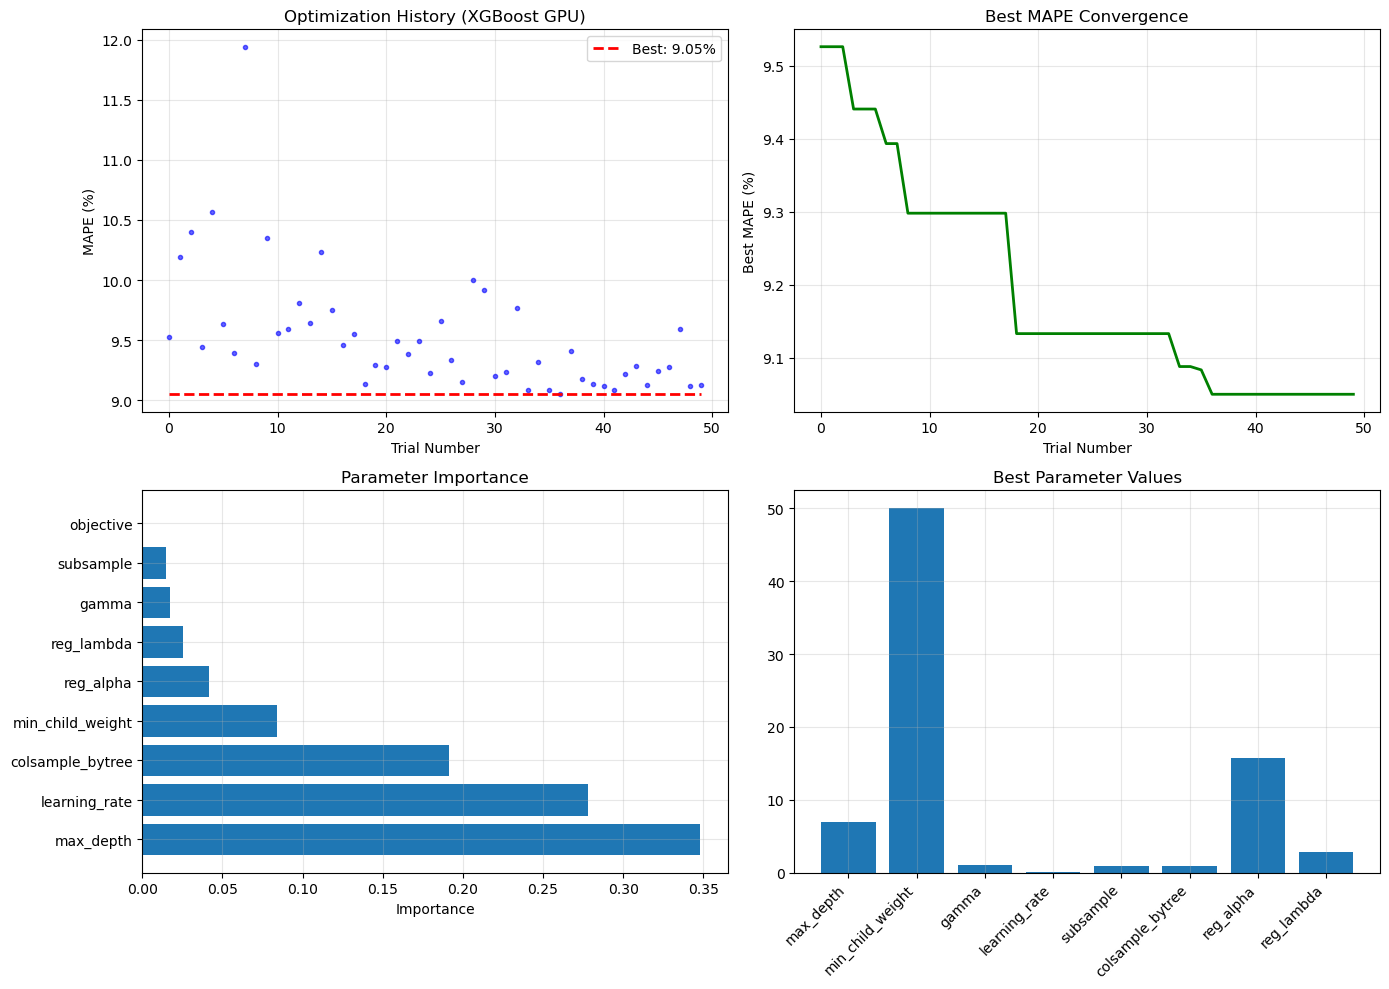


Visualization complete.


In [ ]:
# Cell 5: Optimization Visualization with Residual Analysis
import optuna
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

print("=" * 60)
print("         OPTIMIZATION VISUALIZATION")
print("=" * 60)

# Plot optimization history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
STUDY_NAME = "xgboost_gpu_tuning"
STORAGE_URL = "sqlite:///"+DB_PATH+"tuning_progress.db"
study = optuna.load_study(
    storage=STORAGE_URL,
    study_name=STUDY_NAME,
)

# 1. Optimization history (MAPE values)
axes[0, 0].plot([t.value for t in study.trials], 'b.', alpha=0.6)
axes[0, 0].plot([study.best_value] * len(study.trials), 'r--', linewidth=2, label=f'Best: {study.best_value:.2f}%')
axes[0, 0].set_xlabel('Trial Number')
axes[0, 0].set_ylabel('MAPE (%)')
axes[0, 0].set_title('Optimization History (XGBoost GPU)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Best value over trials (cumulative best)
best_values = []
current_best = float('inf')

for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE and t.value is not None:
        if t.value < current_best:
            current_best = t.value
        best_values.append(current_best)
    elif len(best_values) > 0:
        best_values.append(current_best)
    else:
        best_values.append(float('inf'))

axes[0, 1].plot(best_values, 'g-', linewidth=2)
axes[0, 1].set_xlabel('Trial Number')
axes[0, 1].set_ylabel('Best MAPE (%)')
axes[0, 1].set_title('Best MAPE Convergence')
axes[0, 1].grid(True, alpha=0.3)

# 3. Parameter importance
try:
    if len(study.trials) >= 10:
        param_importance = optuna.importance.get_param_importances(study)
        params = list(param_importance.keys())
        importances = list(param_importance.values())
        axes[1, 0].barh(params, importances)
        axes[1, 0].set_xlabel('Importance')
        axes[1, 0].set_title('Parameter Importance')
        axes[1, 0].grid(True, alpha=0.3)
    else:
        raise ValueError(f'Not enough trials ({len(study.trials)})')
except Exception as e:
    axes[1, 0].text(0.5, 0.7, f'Importance not available\n({str(e)})',
                    ha='center', va='center', transform=axes[1, 0].transAxes,
                    fontsize=10, style='italic')
    axes[1, 0].set_title('Parameter Value Distribution')

# 4. Best parameter values
best_params = study.best_params
numeric_params = {k: v for k, v in best_params.items() if isinstance(v, (int, float))}
if numeric_params:
    axes[1, 1].bar(range(len(numeric_params)), list(numeric_params.values()))
    axes[1, 1].set_xticks(range(len(numeric_params)))
    axes[1, 1].set_xticklabels(list(numeric_params.keys()), rotation=45, ha='right')
    axes[1, 1].set_title('Best Parameter Values')
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nVisualization complete.")

In [ ]:
import cupy as cp


In [ ]:
# Cell 6: Train Final Model with Best Hyperparameters
import time
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import gc

# 1. Prepare Final Training Data
train_full_qdm = xgb.QuantileDMatrix(X_train_full, label=cp.log1p(y_train_full.values))

print("=" * 60)
print("         FINAL MODEL TRAINING")
print("=" * 60)


# Use best hyperparameters from Optuna
best_params = study.best_params
print(f"\nUsing best hyperparameters from tuning:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

# Add GPU parameters and best n_estimators
best_params['seed'] = 42
best_params['seed_per_iteration'] = False
best_params['random_state'] = 42

best_params['tree_method'] = 'hist'
best_params['device'] = 'cuda'
best_params['n_estimators'] = study.best_trial.user_attrs.get('optimal_n_estimators', 100)
best_params['enable_categorical'] = False

# 3. Final Train using num_boost_round from Optuna's best trial
best_iteration = study.best_trial.user_attrs.get('best_iteration', 1000)

print(f"\nFinal model will use {best_params['n_estimators']} trees (from early stopping)")

# Initialize XGBRegressor with best hyperparameters
xgb_model = xgb.XGBRegressor(**best_params)

# Train the model on GPU with early stopping
print(f"Training final Booster with {best_iteration} rounds...")
start_time = time.time()
final_model = xgb.train(
    best_params,
    train_full_qdm,
    num_boost_round=best_iteration
)
train_time = time.time() - start_time
print(f"Training completed in {train_time:.4f} seconds")

# 4. Predict on Holdout
holdout_qdm = xgb.QuantileDMatrix(X_holdout, label=cp.log1p(y_holdout.values), ref=train_full_qdm)

# Make predictions on HOLDOUT set (final evaluation)
print("\nMaking predictions on holdout set (FINAL evaluation)...")
start_time = time.time()
y_pred_log = final_model.predict(holdout_qdm)
predict_time = time.time() - start_time
print(f"Prediction completed in {predict_time:.4f} seconds")

y_pred = np.expm1(y_pred_log)                  # predictions
y_holdout_raw = cp.asnumpy(y_holdout.values).flatten()  # actual values


# 5. Clean up Training Data and Optuna study before metric calculation
del X_train_full, train_full_qdm, holdout_qdm
gc.collect()
cp.get_default_memory_pool().free_all_blocks()

total_trialsF = len(study.trials)
best_trialF = study.best_trial.number
best_MAPEF = study.best_trial.value
optimal_n_estF = study.best_trial.user_attrs.get('optimal_n_estimators', 'N/A')

best_objF = study.best_params.get('objective', 'N/A')
study_best_itemsF = study.best_params.items()
min_child_weightF = study.best_params.get('min_child_weight', 'N/A')
gammaF = study.best_params.get('gamma', 'N/A')

# 5b. Clean up Optuna study and database connection
try:
    if 'study' in globals():
        if hasattr(study, '_storage') and hasattr(study._storage, 'engine'):
            study._storage.engine.dispose()
        del study
        print("\u2713 Optuna study cache cleared (DB connection disposed)")
except Exception as e:
    print(f"Warning: Could not fully clean up study: {e}")

gc.collect()
cp.get_default_memory_pool().free_all_blocks()
print("\u2713 GPU memory fully freed after final training")

# Evaluate model performance with comprehensive metrics
print("Calculating final metrics on CPU...")
r2_test = r2_score(y_holdout_raw, y_pred)
mse_test = mean_squared_error(y_holdout_raw, y_pred)
mae_test = mean_absolute_error(y_holdout_raw, y_pred)

# Calculate MAPE (Mean Absolute Percentage Error)
def mean_absolute_percentage_error(y_true, y_pred):
    """Calculate MAPE - interpretable as percentage error."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mape_test = mean_absolute_percentage_error(y_holdout_raw, y_pred)

print(f"\n" + "=" * 60)
print("         FINAL MODEL EVALUATION (on Holdout Set)")
print("=" * 60)
print(f"Holdout R\u00b2 score: {r2_test:.4f}")
print(f"Holdout MSE: {mse_test:.4f}")
print(f"Holdout RMSE: {np.sqrt(mse_test):.4f}")
print(f"Holdout MAE: {mae_test:.4f}")
print(f"Holdout MAPE: {mape_test:.2f}% (average percentage error)")
print("=" * 60)
print()
print("Metric Interpretations:")
print(f"  - MAE = {mae_test:.4f}: On average, predictions are off by {mae_test:.4f} units")
print(f"  - MAPE = {mape_test:.2f}%: On average, predictions are off by {mape_test:.2f}%")
print(f"  - For real estate: If price is $500k and MAPE is 5%, avg error = $25k")

         FINAL MODEL TRAINING

Using best hyperparameters from tuning:
  max_depth: 7
  min_child_weight: 50
  gamma: 0.9934233474813923
  learning_rate: 0.05201563019900633
  subsample: 0.8677265663043146
  colsample_bytree: 0.8909867866345313
  reg_alpha: 15.67676782329591
  reg_lambda: 2.8598796523011405
  objective: reg:absoluteerror

Final model will use 100 trees (from early stopping)
Training final Booster with 1000 rounds...


/opt/anaconda/envs/rapids-26.04/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [20:33:05] WARNING: /home/task_177741004711274/croot/xgboost-split_1777410104453/work/src/learner.cc:782: 
Parameters: { "enable_categorical", "n_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training completed in 5.5841 seconds

Making predictions on holdout set (FINAL evaluation)...
Prediction completed in 0.0640 seconds
✓ Optuna study cache cleared (DB connection disposed)
✓ GPU memory fully freed after final training
Calculating final metrics on CPU...

         FINAL MODEL EVALUATION (on Holdout Set)
Holdout R² score: 0.9289
Holdout MSE: 2313693952.0000
Holdout RMSE: 48100.8727
Holdout MAE: 26839.7266
Holdout MAPE: 7.61% (average percentage error)

Metric Interpretations:
  - MAE = 26839.7266: On average, predictions are off by 26839.7266 units
  - MAPE = 7.61%: On average, predictions are off by 7.61%
  - For real estate: If price is $500k and MAPE is 5%, avg error = $25k


In [ ]:
# Cell 7: Save the Trained Model (Native XGBoost Format)
import os

print("=" * 60)
print("         MODEL SAVE (Native Booster Format)")
print("=" * 60)

model_path = os.path.join(JSON_PATH,"xgboost_booster.json")

# SAVE using the Booster object from Cell 6
print("Saving model to native XGBoost JSON format...")
# Use 'final_model' (the Booster), not 'xgb_model' (the empty sklearn wrapper)
final_model.save_model(model_path)

file_size = os.path.getsize(model_path)
print(f"Model saved to: {model_path} ({file_size/1024:.2f} KB)")

# Save best parameters separately
params_path = os.path.join(JSON_PATH,"best_params.json")
with open(params_path, 'w') as f:
    json.dump(best_params, f, indent=2)
print(f"Best parameters saved to: {params_path}")

print("\n" + "=" * 60)
print("MODEL SAVED SUCCESSFULLY")
print("=" * 60)

         MODEL SAVE (Native Booster Format)
Saving model to native XGBoost JSON format...
Model saved to: xgb_json/xgboost_booster.json (7866.53 KB)
Best parameters saved to: xgb_json/best_params.json

MODEL SAVED SUCCESSFULLY


In [ ]:
# Cell 7b: Load Model and Make Predictions (STANDALONE — no training required)
# =====================================================================
# This cell is FULLY INDEPENDENT. It does NOT require any previous cell
# to have been run. It loads the saved model and data from disk.
# Any user with these files can run just this cell to get predictions:
#   - xgb_json/xgboost_booster.json
#   - xgb_json/best_params.json
#   - xgb_dataset/X_test.parquet
#   - xgb_dataset/y_test.parquet
#   - xgb_dataset/feature_scaler.pkl
# =====================================================================
import os
import json
import warnings
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Set up paths (must match paths from Cell 1)
DATASET_PATH = "xgb_dataset/"
JSON_PATH = "xgb_json/"

print("=" * 60)
print("         LOAD MODEL & PREDICT (Standalone)")
print("=" * 60)

# ── 1. Load the trained model ──
model_path = os.path.join(JSON_PATH, "xgboost_booster.json")
print(f"Loading trained model from: {model_path}")

import xgboost as xgb
final_model = xgb.XGBRegressor()
final_model.load_model(model_path)
print("✓ Model loaded successfully!")

# ── 2. Load best parameters (for reference) ──
params_path = os.path.join(JSON_PATH, "best_params.json")
if os.path.exists(params_path):
    with open(params_path, 'r') as f:
        best_params = json.load(f)
    print(f"Best parameters loaded from: {params_path}")
    print(f"  Best MAPE: {best_params.get('best_value', 'N/A')}%")
    print(f"  Optimal trees: {best_params.get('optimal_n_estimators', best_params.get('n_estimators', 'N/A'))}")
else:
    print("Note: best_params.json not found (proceeding with model only)")

# ── 3. Load the holdout data ──
print("\nLoading holdout data from parquet files...")
import cudf
import cupy as cp

X_holdout = cudf.read_parquet(os.path.join(DATASET_PATH, 'X_test.parquet'))
y_holdout = cudf.read_parquet(os.path.join(DATASET_PATH, 'y_test.parquet'))

# Ensure float32 for GPU efficiency
X_holdout = X_holdout.astype('float32')
y_holdout = y_holdout.astype('float32')

# Ensure targets are 1D
if hasattr(y_holdout, 'squeeze'):
    y_holdout = y_holdout.squeeze(axis=1)

# Add Time_Index feature if not present (needed for QuantileDMatrix compatibility)
if 'Time_Index' not in X_holdout.columns:
    metadata_path = os.path.join(JSON_PATH, 'metadata.json')
    # with open(metadata_path) as f:
    #     metadata = json.load(f)
    # train_end_idx = metadata['train_end_idx']
    X_holdout['Time_Index'] = cp.arange(train_end_idx, train_end_idx + len(X_holdout))


print(f"  X_holdout: {X_holdout.shape}")
print(f"  y_holdout: {y_holdout.shape}")

# ── 4. Check target scaling ──
y_mean = float(y_holdout.values.mean())
y_std = float(y_holdout.values.std())
target_is_scaled = abs(y_mean) < 2 and 0.5 < y_std < 2

print(f"\nTarget statistics: mean={y_mean:.4f}, std={y_std:.4f}")
if target_is_scaled:
    print("Target appears to be already scaled (z-scores).")
    y_holdout_log = y_holdout.values
else:
    print("Target is raw values. Applying log1p transformation.")
    y_holdout_log = cp.log1p(y_holdout.values)

# ── 5. Make predictions ──
print("\nMaking predictions on holdout set...")
y_pred_log = final_model.predict(X_holdout)
y_pred = np.expm1(y_pred_log)
y_holdout_raw = cp.asnumpy(y_holdout.values) if hasattr(y_holdout.values, 'get') else np.array(y_holdout.values)

# ── 6. Evaluate metrics ──
print("Calculating evaluation metrics...")

r2_test = r2_score(y_holdout_raw, y_pred)
mse_test = mean_squared_error(y_holdout_raw, y_pred)
mae_test = mean_absolute_error(y_holdout_raw, y_pred)

def mean_absolute_percentage_error(y_true, y_pred):
    """Calculate MAPE — interpretable as percentage error."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mape_test = mean_absolute_percentage_error(y_holdout_raw, y_pred)

print(f"\n" + "=" * 60)
print("         FINAL MODEL EVALUATION (on Holdout Set)")
print("=" * 60)
print(f"Holdout R² score: {r2_test:.4f}")
print(f"Holdout MSE: {mse_test:.4f}")
print(f"Holdout RMSE: {np.sqrt(mse_test):.4f}")
print(f"Holdout MAE: {mae_test:.4f}")
print(f"Holdout MAPE: {mape_test:.2f}% (average percentage error)")
print("=" * 60)
print()
print("Metric Interpretations:")
print(f"  - MAE = {mae_test:.4f}: On average, predictions are off by {mae_test:.4f} units")
print(f"  - MAPE = {mape_test:.2f}%: On average, predictions are off by {mape_test:.2f}%")
print(f"  - For real estate: If price is $500k and MAPE is 5%, avg error = $25k")

         LOAD MODEL & PREDICT (Standalone)
Loading trained model from: xgb_json/xgboost_booster.json
✓ Model loaded successfully!
Best parameters loaded from: xgb_json/best_params.json
  Best MAPE: N/A%
  Optimal trees: 100

Loading holdout data from parquet files...
  X_holdout: (13923, 10)
  y_holdout: (13923,)

Target statistics: mean=342787.5625, std=180336.4688
Target is raw values. Applying log1p transformation.

Making predictions on holdout set...
Calculating evaluation metrics...

         FINAL MODEL EVALUATION (on Holdout Set)
Holdout R² score: 0.9289
Holdout MSE: 2313679616.0000
Holdout RMSE: 48100.7237
Holdout MAE: 26839.6543
Holdout MAPE: 7.61% (average percentage error)

Metric Interpretations:
  - MAE = 26839.6543: On average, predictions are off by 26839.6543 units
  - MAPE = 7.61%: On average, predictions are off by 7.61%
  - For real estate: If price is $500k and MAPE is 5%, avg error = $25k


/opt/anaconda/envs/rapids-26.04/lib/python3.12/site-packages/xgboost/core.py:751: UserWarning: [20:33:16] WARNING: /home/task_177741004711274/croot/xgboost-split_1777410104453/work/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cpu, while the input data is on: cuda:0.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


         FEATURE IMPORTANCE ANALYSIS (Gain-Based)


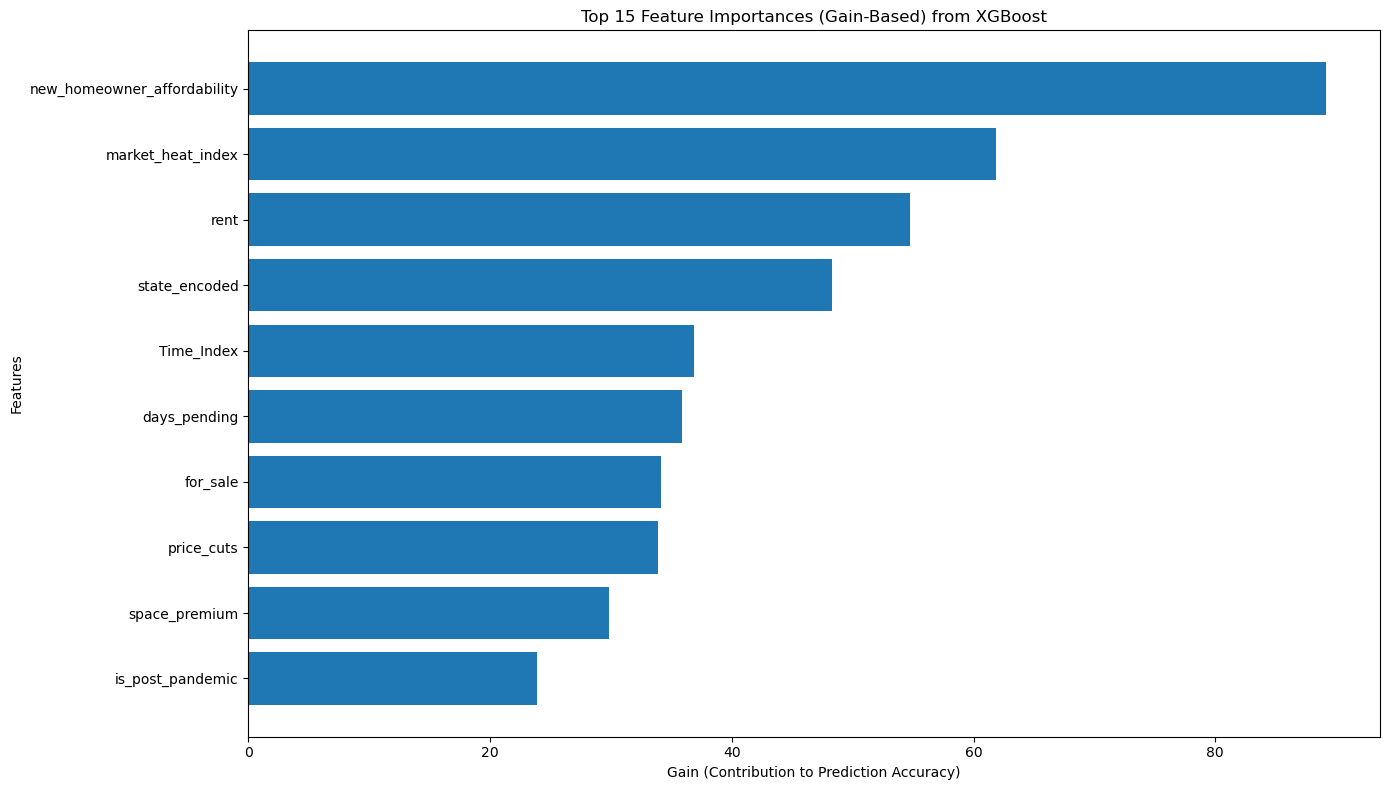


Top 10 Most Important Features (by Gain):
  new_homeowner_affordability: 89.1748
  market_heat_index: 61.8601
  rent: 54.7679
  state_encoded: 48.3303
  Time_Index: 36.8344
  days_pending: 35.8935
  for_sale: 34.1592
  price_cuts: 33.8675
  space_premium: 29.8617
  is_post_pandemic: 23.8806

#ASSUMPTION: Gain shows actual contribution to prediction accuracy
  - High gain = feature significantly improves predictions
  - More meaningful than 'weight' (split frequency) for real estate


In [ ]:
# Cell 8: Feature Importance Analysis (Gain-Based)
import matplotlib.pyplot as plt

print("=" * 60)
print("         FEATURE IMPORTANCE ANALYSIS (Gain-Based)")
print("=" * 60)

# Get the underlying booster (works for both Booster and XGBRegressor)
if hasattr(final_model, 'get_booster'):
    booster = final_model.get_booster()
else:
    booster = final_model
importance = booster.get_score(importance_type='gain')


# Convert to arrays for plotting
feature_names_xgb = list(importance.keys())
feature_importances = list(importance.values())

# Sort by importance
indices = np.argsort(feature_importances)[::-1]
feature_names_sorted = [feature_names_xgb[i] for i in indices]
feature_importances_sorted = [feature_importances[i] for i in indices]

# Plot feature importances
plt.figure(figsize=(14, 8))
top_n = min(15, len(feature_importances_sorted))

plt.barh(range(top_n), feature_importances_sorted[:top_n][::-1])
plt.yticks(range(top_n), feature_names_sorted[:top_n][::-1])
plt.xlabel('Gain (Contribution to Prediction Accuracy)')
plt.ylabel('Features')
plt.title('Top 15 Feature Importances (Gain-Based) from XGBoost')
plt.tight_layout()
plt.show()

# Print top 10 most important features
print(f"\nTop 10 Most Important Features (by Gain):")
for i in range(min(10, len(feature_importances_sorted))):
    print(f"  {feature_names_sorted[i]}: {feature_importances_sorted[i]:.4f}")

print("\n#ASSUMPTION: Gain shows actual contribution to prediction accuracy")
print("  - High gain = feature significantly improves predictions")
print("  - More meaningful than 'weight' (split frequency) for real estate")

         FINAL PROJECT SUMMARY REPORT


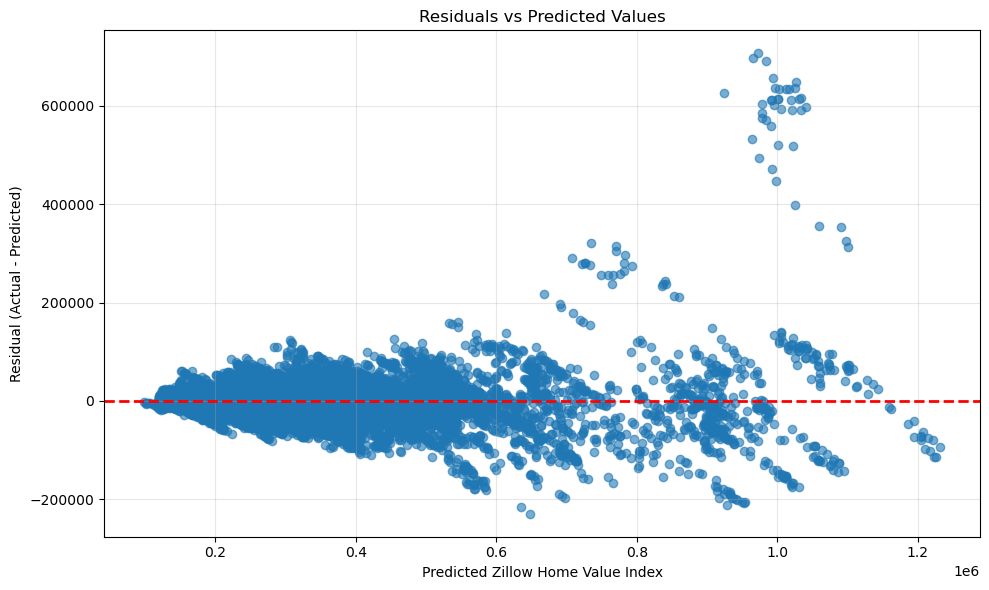


GPU-Accelerated XGBoost Regressor - Final Project Report

Generated: 2026-05-12 20:33:25

1. DATA SUMMARY
   - Total samples: 92,748
   - Features: 10
   - Training samples: 78825
   - Validation samples (for Optuna): 19707
   - Holdout samples (FINAL evaluation): 13,923
   - Target transformation: log1p (stabilizes variance)

2. GPU OPTIMIZATION
   - Data type: float32 (50% memory reduction)
   - Tree method: hist (GPU-optimized histogram)
   - QuantileDMatrix: Pre-calculated bins (saves minutes)
   - MAPE calculation: GPU-based (avoids CPU transfer)

3. HYPERPARAMETER TUNING (Optuna with Early Stopping)
   - Total trials: 50
   - Best trial: 36
   - Best MAPE: 9.05%
   - Optimal n_estimators: None
   - Best objective: reg:absoluteerror
   - Best hyperparameters:
     - max_depth: 7
     - min_child_weight: 50
     - gamma: 0.9934233474813923
     - learning_rate: 0.05201563019900633
     - subsample: 0.8677265663043146
     - colsample_bytree: 0.8909867866345313
     - reg_alpha: 15

In [ ]:
# Cell 9: Generate Summary Report with Future Work
from datetime import datetime
import matplotlib.pyplot as plt
import json

print("=" * 60)
print("         FINAL PROJECT SUMMARY REPORT")
print("=" * 60)

# Load tuning results from JSON (works with or without training pipeline)
tuning_results_path = os.path.join(JSON_PATH, 'tuning_results.json')
if os.path.exists(tuning_results_path):
    with open(tuning_results_path, 'r') as f:
        tuning_results = json.load(f)
    total_trialsF = tuning_results.get('n_trials', 'N/A')
    best_trialF = tuning_results.get('best_trial', 'N/A')
    best_MAPEF = tuning_results.get('best_value', 'N/A')
    optimal_n_estF = tuning_results.get('optimal_n_estimators', 'N/A')
    best_objF = tuning_results.get('best_objective', 'N/A')
    tuning_params = tuning_results.get('best_params', {})
    study_best_itemsF = list(tuning_params.items())
    min_child_weightF = tuning_params.get('min_child_weight', 'N/A')
    gammaF = tuning_params.get('gamma', 'N/A')
else:
    # Fallback: try loading best_params.json directly
    params_fallback_path = os.path.join(JSON_PATH, 'best_params.json')
    if os.path.exists(params_fallback_path):
        with open(params_fallback_path, 'r') as f:
            tuning_params = json.load(f)
        study_best_itemsF = list(tuning_params.items())
        min_child_weightF = tuning_params.get('min_child_weight', 'N/A')
        gammaF = tuning_params.get('gamma', 'N/A')
    else:
        study_best_itemsF = []
        min_child_weightF = 'N/A'
        gammaF = 'N/A'
    total_trialsF = best_trialF = best_MAPEF = optimal_n_estF = best_objF = 'N/A'

# Store predictions for residual analysis
residuals = y_holdout_raw - y_pred
# Create residual plot for the report
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_pred, residuals, alpha=0.6)
ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Predicted Zillow Home Value Index')
ax.set_ylabel('Residual (Actual - Predicted)')
ax.set_title('Residuals vs Predicted Values')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SUMMARY_PATH,'residual_plot.png'), dpi=150)
plt.show()

report = f"""
GPU-Accelerated XGBoost Regressor - Final Project Report
============================================================

Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

1. DATA SUMMARY
   - Total samples: {training_size + len(X_holdout):,}
   - Features: {X_holdout.shape[1]}
   - Training samples: {training_size}
   - Validation samples (for Optuna): {validation_size}
   - Holdout samples (FINAL evaluation): {len(X_holdout):,}
   - Target transformation: log1p (stabilizes variance)

2. GPU OPTIMIZATION
   - Data type: float32 (50% memory reduction)
   - Tree method: hist (GPU-optimized histogram)
   - QuantileDMatrix: Pre-calculated bins (saves minutes)
   - MAPE calculation: GPU-based (avoids CPU transfer)

3. HYPERPARAMETER TUNING (Optuna with Early Stopping)
   - Total trials: {total_trialsF}
   - Best trial: {best_trialF}
   - Best MAPE: {best_MAPEF:.2f}%
   - Optimal n_estimators: {optimal_n_estF}
   - Best objective: {best_objF}
   - Best hyperparameters:
"""

for key, value in study_best_itemsF:
    report += f"     - {key}: {value}\n"

report += f"""
4. FINAL MODEL PERFORMANCE (on Holdout Set)
   - Holdout R\u00b2: {r2_test:.4f}
   - Holdout MSE: {mse_test:.4f}
   - Holdout RMSE: {np.sqrt(mse_test):.4f}
   - Holdout MAE: {mae_test:.4f} (interpretable in actual units)
   - Holdout MAPE: {mape_test:.2f}% (average percentage error)

5. METRIC INTERPRETATIONS
   - MAE: On average, predictions are off by {mae_test:.4f} units
   - MAPE: On average, predictions are off by {mape_test:.2f}%
   - For real estate: If price is $500k and MAPE is 5%, avg error = $25k

6. OVERFITTING PREVENTION
   - min_child_weight: {min_child_weightF} (prevents single-zip leaves)
   - gamma: {gammaF} (requires minimum loss reduction)
   - Early stopping: 50 rounds (automatically finds optimal trees)

7. TOP 5 MOST IMPORTANT FEATURES (Gain-Based)
"""

for i in range(min(5, len(feature_importances_sorted))):
    report += f"   - {feature_names_sorted[i]}: {feature_importances_sorted[i]:.4f}\n"

report += f"""
8. FILES GENERATED
   - Model: {model_path} (native XGBoost JSON)
   - Parameters: {params_path}
   - Tuning results: tuning_results.json
   - Residual plot: residual_plot.png
   - Optuna database: tuning_progress.db

9. FUTURE WORK: Multi-GPU Scaling with Dask
   For production deployment at Zillow scale (millions of properties),
   this single-GPU implementation would be extended using Dask:

   ```python
   import dask_cuml
   from dask_xgboost import XGBRegressor

   # Distribute across GPU cluster
   client = Client(n_workers=4, threads_per_worker=1, processes=False)

   # Dask-aware XGBoost
   model = XGBRegressor(tree_method='hist', device='cuda')
   model.fit(dask_X_train, dask_y_train)
   ```

   Benefits:
   - Horizontal scaling across multiple GPUs
   - Handle datasets larger than single GPU memory
   - Faster hyperparameter tuning with distributed Optuna

============================================================
"""

print(report)

# Save report to file
with open(os.path.join(SUMMARY_PATH,'project_report.txt'), 'w') as f:
    f.write(report)

print("Report saved to: project_report.txt")
print("=" * 60)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path = ''
scaler_path = base_path + 'Dataset/Model_Ready_Exports/feature_scaler.pkl'
x_test_path = base_path + 'Dataset/Model_Ready_Exports/X_test.parquet'
y_test_path = base_path + 'Dataset/Model_Ready_Exports/y_test.parquet'
xgb_model_path = base_path + 'XGB/xgb_json/xgboost_booster.json' #Modified to new path json

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import joblib
import xgboost as xgb
from sklearn.linear_model import LinearRegression

In [ ]:
# load data and scaler
scaler = joblib.load(scaler_path)
X_test = pd.read_parquet(x_test_path)
y_test = pd.read_parquet(y_test_path).squeeze()

In [ ]:
# reconstruct MLR model (coefficients from Vince’s notebook)
mlr = LinearRegression()
mlr.intercept_ = 12.0586

mlr.coef_ = np.array([
    0.205389,   # rent
    0.006595,   # for_sale
   -0.043229,   # days_pending
    0.027659,   # price_cuts
    0.088828,   # market_heat_index
    0.022907,   # new_homeowner_affordability
   -0.076276,   # space_premium
    0.025667,   # is_post_pandemic
    0.084938    # state_encoded
])

In [ ]:
# load XGBoost booster
xgb_booster = xgb.Booster()
xgb_booster.load_model(xgb_model_path)
dtest = xgb.DMatrix(X_test.values, feature_names=X_test.columns.tolist())

In [ ]:
# sample for SHAP (2000 rows)
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=min(2000, len(X_test)), replace=False)
X_sample = X_test.iloc[sample_idx]
dtest_sample = xgb.DMatrix(X_sample.values, feature_names=X_test.columns.tolist())

In [ ]:
# MLR SHAP (LinearExplainer)
print("Running LinearExplainer...")
explainer_linear = shap.LinearExplainer(mlr, X_test, feature_perturbation="interventional")
shap_values_linear = explainer_linear.shap_values(X_sample)

# Bar plot
plt.figure()
shap.summary_plot(shap_values_linear, X_sample, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig('shap_mlr_bar.png', dpi=300)
plt.close()

# Beeswarm
plt.figure()
shap.summary_plot(shap_values_linear, X_sample, show=False)
plt.tight_layout()
plt.savefig('shap_mlr_beeswarm.png', dpi=300)
plt.close()

Running LinearExplainer...


/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)
/tmp/ipykernel_1728/3660356659.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_linear, X_sample, plot_type="bar", show=False)
/tmp/ipykernel_1728/3660356659.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_linear, X_sample, show=False)


In [ ]:
# Check what features the XGBoost model expects
print("Booster feature names:", xgb_booster.feature_names)
print("X_test columns:", X_test.columns.tolist())
print("Booster num features:", getattr(xgb_booster, 'num_features', 'unknown'))

Booster feature names: ['rent', 'for_sale', 'days_pending', 'price_cuts', 'market_heat_index', 'new_homeowner_affordability', 'space_premium', 'is_post_pandemic', 'state_encoded', 'Time_Index']
X_test columns: ['rent', 'for_sale', 'days_pending', 'price_cuts', 'market_heat_index', 'new_homeowner_affordability', 'space_premium', 'is_post_pandemic', 'state_encoded']
Booster num features: <bound method Booster.num_features of <xgboost.core.Booster object at 0x78bdff969fd0>>


In [ ]:
start_idx = int(112455 - len(X_test))   # should be 98532
X_test['Time_Index'] = np.arange(start_idx, start_idx + len(X_test))

# Ensure the columns are in the exact order the booster expects
expected_cols = ['rent', 'for_sale', 'days_pending', 'price_cuts', 'market_heat_index',
                 'new_homeowner_affordability', 'space_premium', 'is_post_pandemic',
                 'state_encoded', 'Time_Index']
X_test = X_test[expected_cols]

# Recreate the DMatrix and the sample
dtest = xgb.DMatrix(X_test.values, feature_names=expected_cols)
X_sample = X_test.iloc[sample_idx]
dtest_sample = xgb.DMatrix(X_sample.values, feature_names=expected_cols)

print("Time_Index added. X_test now has", X_test.shape[1], "features.")

Time_Index added. X_test now has 10 features.


In [ ]:
# XGBoost SHAP (TreeExplainer)
print("Running TreeExplainer...")
explainer_tree = shap.TreeExplainer(xgb_booster)
shap_values_tree = explainer_tree.shap_values(dtest_sample)

# Bar plot
plt.figure()
shap.summary_plot(shap_values_tree, X_sample, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig('shap_xgb_bar.png', dpi=300)
plt.close()

# Beeswarm
plt.figure()
shap.summary_plot(shap_values_tree, X_sample, show=False)
plt.tight_layout()
plt.savefig('shap_xgb_beeswarm.png', dpi=300)
plt.close()

# Dependence plots for top 5 features
mean_abs_shap = np.abs(shap_values_tree).mean(axis=0)
top_indices = np.argsort(mean_abs_shap)[::-1][:5]

for feat_idx in top_indices:
    feat_name = X_test.columns[feat_idx]
    plt.figure()
    shap.dependence_plot(
        ind=feat_idx,
        shap_values=shap_values_tree,
        features=X_sample,
        feature_names=X_test.columns.tolist(),
        show=False
    )
    plt.tight_layout()
    plt.savefig(f'shap_xgb_dependence_{feat_name}.png', dpi=300)
    plt.close()

print("All SHAP plots saved to the current Colab directory.")

Running TreeExplainer...


/tmp/ipykernel_1728/3187307280.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_tree, X_sample, plot_type="bar", show=False)
/tmp/ipykernel_1728/3187307280.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_tree, X_sample, show=False)


All SHAP plots saved to the current Colab directory.


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
import shutil, glob
dest = base_path + 'FINAL PROJECT/XGB/'
shutil.copy('shap_mlr_bar.png', dest)
shutil.copy('shap_mlr_beeswarm.png', dest)
shutil.copy('shap_xgb_bar.png', dest)
shutil.copy('shap_xgb_beeswarm.png', dest)
for f in glob.glob('shap_xgb_dependence_*.png'):
    shutil.copy(f, dest)